# 2 · Sensitivity analysis

The calibration in notebook 1 fits every demand parameter to a national panel, and each
fit carries a sampling uncertainty. This notebook propagates that uncertainty through the
model to ask two questions: which parameters move annual demand the most, and whether that
ordering holds across cities with different housing stocks. Answering them is what lets the
paper report the model's reliability as the propagated standard error of the fits rather
than a guess.

The screen is a Morris elementary-effects design
([`sa_morris.py`](../../../research/applied/scripts/sa_morris.py)). Each parameter is
stepped within its published $\pm 2$ standard errors, and the mean absolute effect $\mu^*$
ranks the parameters by influence; the standard deviation $\sigma$ of the effects measures
interaction and non-linearity. The design consumes the same parameter set and bootstrap
standard errors the calibration produced, so the sensitivity is tied to the fits, not to
arbitrary ranges.

Heavy steps read the committed screen by default, so a full run is fast; `RUN_SA`
recomputes it live (slow), calling the same `sa_morris.py` the command line runs.

> **Provenance flag.** The committed screen was run on the v5 parameter set
> (`calibration_v5_phase5b_boot`), before the v7 cohort re-calibration. The influence
> *structure* is what the analysis claims and the two share the same parameter families, so
> the ranking carries over, but a v7 re-run is a pending update. One number to read with
> care: the baseline electricity anchor here still carries the v5 recentring that v7
> removed.

In [1]:
import sys, os, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "household_energy").exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
SCRIPTS = REPO / "research" / "applied" / "scripts"
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(SCRIPTS))
SA_DIR = REPO / "results" / "sensitivity_analysis"
BOOT_DIR = REPO / "results" / "calibration_v5_phase5b_boot"   # SERL bootstrap the SE table is built from

# Read the dated run notebook 1 stamped (latest by default), and deposit into it.
import run_paths
RUN_DATE = None
RUN = run_paths.run_dir(RUN_DATE, create=True)
CONFIG = run_paths.config_for(RUN_DATE)   # the run's frozen config, else the latest working copy

# The full screen chain, each step reachable from here. Defaults read committed artefacts.
RUN_BOOTSTRAP   = False   # re-bootstrap the SERL fits' standard errors (calibrate_serl --bootstrap, slow)
RUN_PARAM_TABLE = False   # rebuild sa_param_table from the bootstrap dir (fast)
RUN_SA          = False   # re-run the Morris screen (slow)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

if RUN_BOOTSTRAP:
    subprocess.run([sys.executable, str(SCRIPTS / "calibrate_serl.py"),
                    "--bootstrap", "200", "--label", "phase5b_boot_rerun"], check=True)
    BOOT_DIR = REPO / "results" / "calibration_phase5b_boot_rerun"
if RUN_PARAM_TABLE:
    subprocess.run([sys.executable, str(SCRIPTS / "build_sa_param_table.py"),
                    "--calib-dir", str(BOOT_DIR)], check=True)   # writes SA_DIR/sa_param_table.{yaml,csv}
if RUN_SA:
    from sa_morris import main as run_morris
    run_morris(["--city", "newcastle", "--year", "2023", "--r", "8"])   # same code path as the CLI

print("run:", RUN.relative_to(REPO), "| config:", CONFIG.relative_to(REPO), "exists:", CONFIG.exists())
print("reading screen from", SA_DIR.relative_to(REPO))

run: results/runs/2026-06-24 | config: results/runs/2026-06-24/calibrated_config.yaml exists: True
reading screen from results/sensitivity_analysis


## 2.1 · Influence ranking (Newcastle 2023)

Each bar is a parameter's mean absolute effect $\mu^*$ on annual city demand, as a
percentage of the baseline, for a step of $\pm 2$ standard errors. Colour marks which term
of the demand equation the parameter belongs to: baseline $B$, heating $H$, or occupancy
$S$.

The ordering is unambiguous: the heating term dominates. The setpoint and the building-age,
SAP, and floor-area multipliers that make up $\rho_d$ are the most influential, each near
two per cent per step, while the baseline anchors and the per-person load move demand far
less. No single parameter shifts annual demand by more than about 2.2 per cent, so the
calibrated envelope is tight. Because the signed mean $\mu$ tracks $\mu^*$ and $\sigma$ is
small, the response is close to linear with little interaction; the model does not hide a
parameter that is quiet alone but violent in combination.

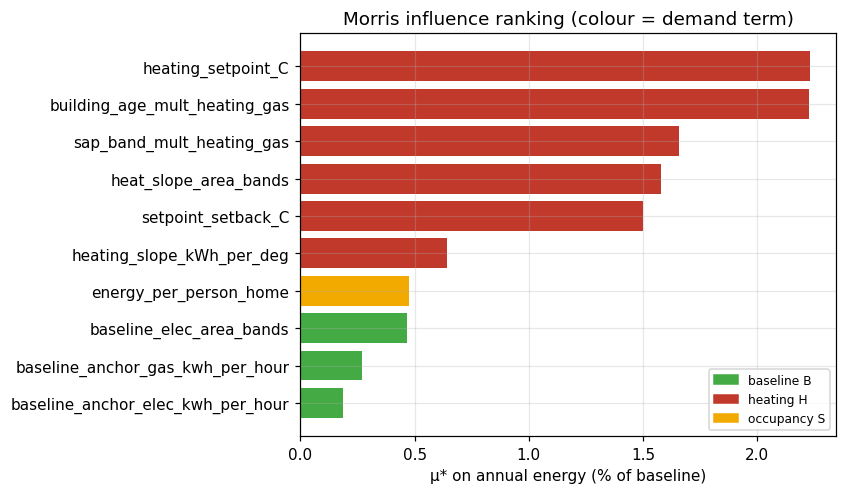

largest single-parameter effect: 2.2% per ±2·SE step

parameter table (central value, uncertainty, source):
                             knob       central                uncertainty                                                             source
               heating_setpoint_C        16.468     ±2·SE = ±0.1703 (0.5%)             SERL temperature-band hinge fit (parametric bootstrap)
        heating_slope_kWh_per_deg       0.20967   ±2·SE = ±0.001165 (0.3%)                 SERL HDD OLS-through-origin (in-process bootstrap)
 baseline_anchor_gas_kwh_per_hour       0.28863   ±2·SE = ±0.002774 (0.5%)                    SERL summer gas baseline (in-process bootstrap)
baseline_anchor_elec_kwh_per_hour       0.38155   ±2·SE = ±0.001659 (0.2%)        SERL summer elec baseline, recentred (in-process bootstrap)
           energy_per_person_home      0.030414   ±2·SE = ±0.003434 (5.6%)        SERL diurnal per-person (cross-seg unconfounded, bootstrap)
            heat_slope_area_bands 5-band

In [2]:
sa = pd.read_csv(SA_DIR / "sa_morris_newcastle.csv").sort_values("mu_star_energy_pct_base")
ptab = pd.read_csv(SA_DIR / "sa_param_table.csv")

# Map each knob to its demand term, for colour.
TERM = {
    "heating_setpoint_C": "H", "setpoint_setback_C": "H", "heating_slope_kWh_per_deg": "H",
    "heat_slope_area_bands": "H", "sap_band_mult_heating_gas": "H",
    "building_age_mult_heating_gas": "H",
    "baseline_anchor_gas_kwh_per_hour": "B", "baseline_anchor_elec_kwh_per_hour": "B",
    "baseline_elec_area_bands": "B",
    "energy_per_person_home": "S",
}
COL = {"B": "#4a4", "H": "#c0392b", "S": "#f2a900"}
colors = [COL.get(TERM.get(k, ""), "#888") for k in sa.knob]

fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.barh(sa.knob, sa.mu_star_energy_pct_base, color=colors)
ax.set(xlabel="μ* on annual energy (% of baseline)", title="Morris influence ranking (colour = demand term)")
handles = [plt.Rectangle((0, 0), 1, 1, color=COL[t]) for t in ["B", "H", "S"]]
ax.legend(handles, ["baseline B", "heating H", "occupancy S"], fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print(f"largest single-parameter effect: {sa.mu_star_energy_pct_base.max():.1f}% per ±2·SE step")
print("\nparameter table (central value, uncertainty, source):")
print(ptab[["knob", "central", "uncertainty", "source"]].to_string(index=False))

# Freeze the ranking into the dated run snapshot (pre-v7 screen; see the provenance flag).
sa.to_csv(RUN / "sensitivity_morris_newcastle.csv", index=False)
print("\ndeposited ->", (RUN / "sensitivity_morris_newcastle.csv").relative_to(REPO))

## 2.2 · Cross-city robustness

The ranking should be a property of the model and the fits, not of Newcastle's particular
stock. Re-running the screen on four further cities with different building mixes, the
heating parameters stay on top everywhere: the setpoint, building age, and SAP band are the
three largest effects in all five cities, each within a narrow band around two per cent.
The influence structure transfers, which is the same property the spatial validation in
notebook 3 tests on demand levels.

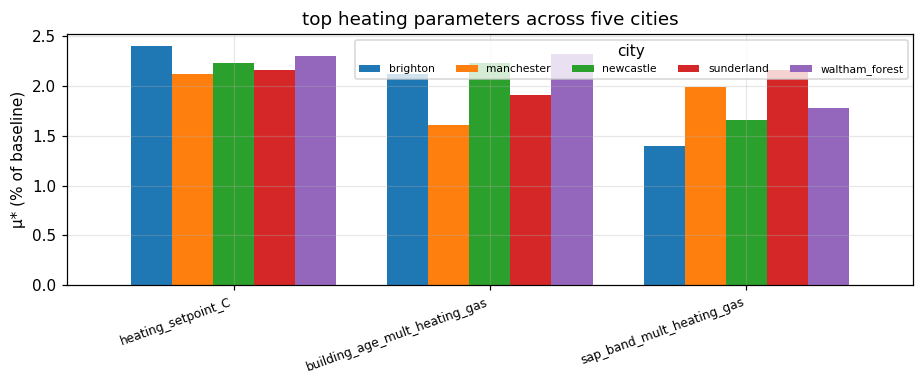

city                           brighton  manchester  newcastle  sunderland  waltham_forest
knob                                                                                      
heating_setpoint_C                 2.40        2.12       2.23        2.16            2.30
building_age_mult_heating_gas      2.12        1.60       2.22        1.91            2.32
sap_band_mult_heating_gas          1.40        1.99       1.66        2.16            1.78


In [3]:
p5 = SA_DIR / "sa_morris_5city.csv"
if p5.exists():
    sa5 = pd.read_csv(p5)
    piv = sa5.pivot_table(index="knob", columns="city", values="mu_star_pct")
    piv = piv.reindex(piv.mean(axis=1).sort_values(ascending=False).index)
    fig, ax = plt.subplots(figsize=(8.5, 3.6))
    piv.plot(kind="bar", ax=ax, width=0.8)
    ax.set(ylabel="μ* (% of baseline)", xlabel="", title="top heating parameters across five cities")
    ax.legend(title="city", fontsize=7, ncol=5)
    plt.xticks(rotation=20, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()
    print(piv.round(2).to_string())
else:
    print("sa_morris_5city.csv not found; run the 5-city screen to populate.")